In [150]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time

In [151]:
from DataProcessing.Plot import PlotSaver

In [152]:
ps = PlotSaver("X:\\migratedData\\Rydberg_QIS\\data")

In [153]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [154]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [155]:
sr400 = SR400.SR400('GPIB0::23::INSTR',timeout=1000)

In [156]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [207]:
weeder.position(header = "A", query = True)

'A3400'

In [188]:
weeder.move(header = "A", position = 3400)

Old position: 3000
New position: 3400


In [206]:
weeder.advance(header = "A", num_step = -10)

In [157]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],   # MOT
                     [["B", 10e-6, 5e-6, 15],    # 780 excitation 20dB attenuator connected
                      ["C", 10e-6, 5e-6, "TTL"]],    # 480 exc
                     ["D", 20e-6, 0, 8],        # DEI switch
                    ]
T = 0.001

cycle_number = 100
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

In [158]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num=cycle_number, dwell=0, sourceA="INPUT1",sourceB="INPUT2", gate_A_mode="FIXED", gate_A_delay=gate_delay,
                gate_A_width=gate_width,gate_B_mode="CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 100
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [159]:
bnc575.clock_set(period=T,mode="CONTINUOUS")
bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [160]:
bnc575.start_pulses()

In [ ]:
bnc575.disarm_all()

In [ ]:
sr400.count_reset()

In [ ]:
sig_list = sr400.read_entire_counts(counter="A",length = cycle_number)

In [ ]:
x = np.arange(cycle_number)+1
ps.Plot2D(x,y = T, Z = sig_list,xlabel="cycle number",zlabel="counting")

In [ ]:
plt.scatter(x,sig_list)

In [208]:
delta = 1000
center = 3400

start_position = center - delta
weeder.move(header = "A", position = start_position)

x_list = np.arange(2*delta)
results = []

for idx in x_list:
    print("now checking step: {}".format(idx))
    sr400.count_reset()
    time.sleep(0.1)
    result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    results.append(result)
    weeder.advance(header = "A", num_step = 1)
    time.sleep(0.1)

Old position: 3400
New position: 2400
now checking step: 0
One entire measurement is done, the last count is 0
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
now checking step: 1
One entire measurement is done, the last count is 0
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
now checking step: 2
One entire measurement is done, the last count is 0
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

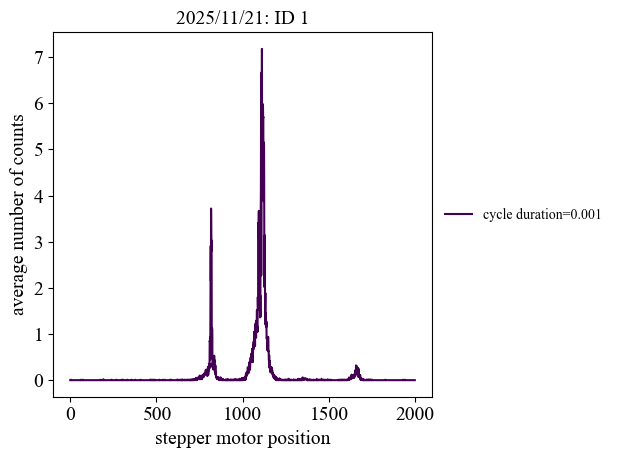

In [209]:
ps.Plot2D(x = x_list, y = T, Z = results, xlabel = "stepper motor position", ylabel = "cycle duration", zlabel = "average number of counts")

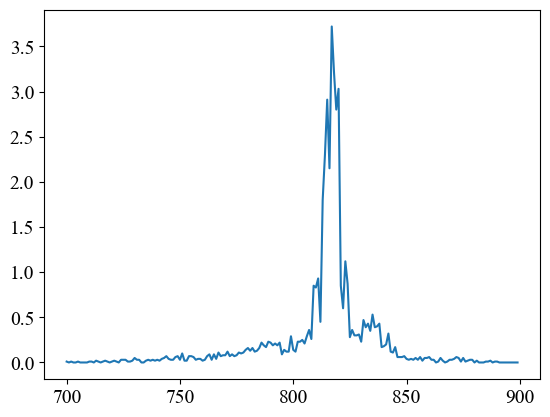

In [212]:
plt.plot(x_list[700:900],results[700:900])

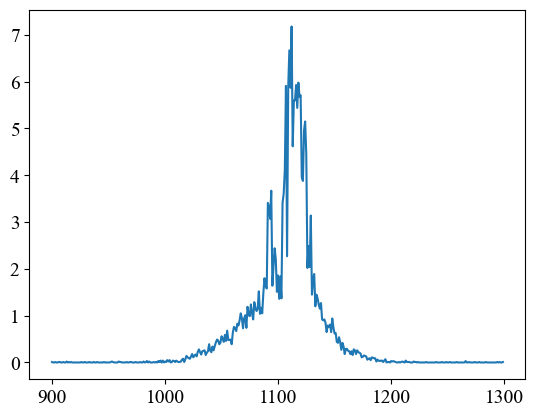

In [213]:
plt.plot(x_list[900:1300],results[900:1300])

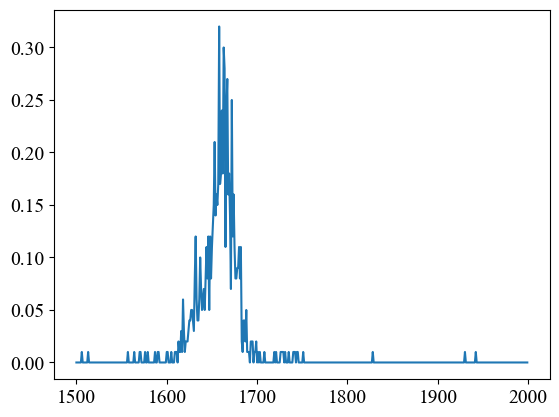

In [214]:
plt.plot(x_list[1500:2000],results[1500:2000])

**5P 3/2 -- 50 D 3/2 resonance at stepper motor position 3722.**

In [ ]:
weeder.save(header = "A", query = True)